# Customer Classification – Bank Marketing Dataset
## Supervised Binary Classification

**Objective:** Build a Machine Learning model to predict whether a customer will respond positively to a marketing campaign (subscribe to a term deposit).

**Dataset:** UCI Machine Learning Repository – Bank Marketing Dataset

**Author:** Student  
**Date:** 2024

---
**Business Context (E-commerce perspective):**

> If a business has customer behavioral and demographic data, a predictive model can help identify customer segments with high conversion probability — enabling targeted advertising, voucher allocation, email marketing, and remarketing strategies.

---

## Part 1 – Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay,
)

# Settings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# Output directories
FIGURES_DIR = Path("../outputs/figures")
RESULTS_DIR = Path("../outputs/results")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("All libraries imported successfully.")

All libraries imported successfully.


## Part 2 – Load Data

Dataset: **Bank Marketing** from [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/bank+marketing)

The data is related to direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe to a term deposit (variable `y`).

In [2]:
# Load dataset using relative path
DATA_PATH = Path("../data/bank-additional-full.csv")
df = pd.read_csv(DATA_PATH, sep=";")
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded: 41188 rows × 21 columns


In [3]:
# First 5 rows
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
# Dataset shape
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 41188
Number of columns: 21


In [5]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
# Statistical summary for all columns
df.describe(include="all")

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188,41188,41188,41188,41188,41188,41188,41188,41188,...,41188.000000,41188.000000,41188.000000,41188,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188
unique,NaN,12,4,8,3,3,3,2,10,5,...,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,2
top,NaN,admin.,married,university.degree,no,yes,no,cellular,may,thu,...,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,no
freq,NaN,10422,24928,12168,32588,21576,33950,26144,13769,8623,...,NaN,NaN,NaN,35563,NaN,NaN,NaN,NaN,NaN,36548
mean,40.02406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.567593,962.475454,0.172963,NaN,0.081886,93.575664,-40.502600,3.621291,5167.035911,NaN
std,10.42125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.770014,186.910907,0.494901,NaN,1.570960,0.578840,4.628198,1.734447,72.251528,NaN
min,17.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,NaN
25%,32.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,NaN
50%,38.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,999.000000,0.000000,NaN,1.100000,93.749000,-41.800000,4.857000,5191.000000,NaN
75%,47.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,NaN


### Data Overview

**Features:**
- **Numerical features:** `age`, `duration`, `campaign`, `pdays`, `previous`, `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`
- **Categorical features:** `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `day_of_week`, `poutcome`
- **Target:** `y` (yes/no — whether the client subscribed to a term deposit)

The dataset contains both client demographic information and campaign-related attributes.

## Part 3 – Data Cleaning

In [7]:
# Check for missing values (NaN)
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Total missing: 0


In [8]:
# Check for duplicate rows
n_dup = df.duplicated().sum()
print(f"Number of duplicate rows: {n_dup}")
if n_dup > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"After removal: {df.shape[0]} rows remain")

Number of duplicate rows: 12
After removal: 41176 rows remain


### Handling "unknown" Values

The dataset uses `"unknown"` as a placeholder for missing data in categorical columns. Let's analyze the distribution of unknowns.

In [9]:
# Analyze 'unknown' values in categorical columns
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols = [c for c in categorical_cols if c != "y"]  # exclude target

unknown_summary = []
for col in categorical_cols:
    n_unknown = (df[col] == "unknown").sum()
    pct_unknown = n_unknown / len(df) * 100
    unknown_summary.append({"Column": col, "Unknown Count": n_unknown, "Unknown %": round(pct_unknown, 2)})

unknown_df = pd.DataFrame(unknown_summary).sort_values("Unknown %", ascending=False)
unknown_df

,Column,Unknown Count,Unknown %
3,default,8596,20.88
2,education,1730,4.20
4,housing,990,2.40
5,loan,990,2.40
0,job,330,0.80
1,marital,80,0.19
6,contact,0,0.00
7,month,0,0.00
8,day_of_week,0,0.00
9,poutcome,0,0.00


### Unknown Value Treatment Strategy

- **Columns with low unknown rate (< 20%):** Replace `"unknown"` with `NaN` and let the imputer handle them (most frequent strategy).
- **Columns with high unknown rate (≥ 20%):** Keep `"unknown"` as a valid category to avoid discarding too much information.
- **`default` column:** Has a very high unknown rate — keeping "unknown" as a category is more appropriate since replacing ~20% of data with the mode would introduce bias.

**Rationale:** Blindly removing all rows with `"unknown"` would significantly reduce the dataset size and could introduce selection bias. Using imputation or keeping "unknown" preserves data integrity.

In [10]:
# Apply unknown value treatment
df_clean = df.copy()

# Columns where we replace 'unknown' with NaN (low unknown rate < 20%)
low_unknown_cols = unknown_df[unknown_df["Unknown %"] < 20]["Column"].tolist()
# Exclude 'default' even if it's < 20% due to its special nature
high_unknown_cols = unknown_df[unknown_df["Unknown %"] >= 20]["Column"].tolist()

print("Columns with 'unknown' replaced by NaN (to be imputed):", low_unknown_cols)
print("Columns keeping 'unknown' as category:", high_unknown_cols)

for col in low_unknown_cols:
    df_clean[col] = df_clean[col].replace("unknown", np.nan)

print(f"\nMissing values after treatment:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Columns with 'unknown' replaced by NaN (to be imputed): ['education', 'housing', 'loan', 'job', 'marital', 'contact', 'month', 'day_of_week', 'poutcome']
Columns keeping 'unknown' as category: ['default']

Missing values after treatment:
job           330
marital        80
education    1730
housing       990
loan          990
dtype: int64


## Part 4 – Exploratory Data Analysis (EDA)

### 4.1 Target Distribution

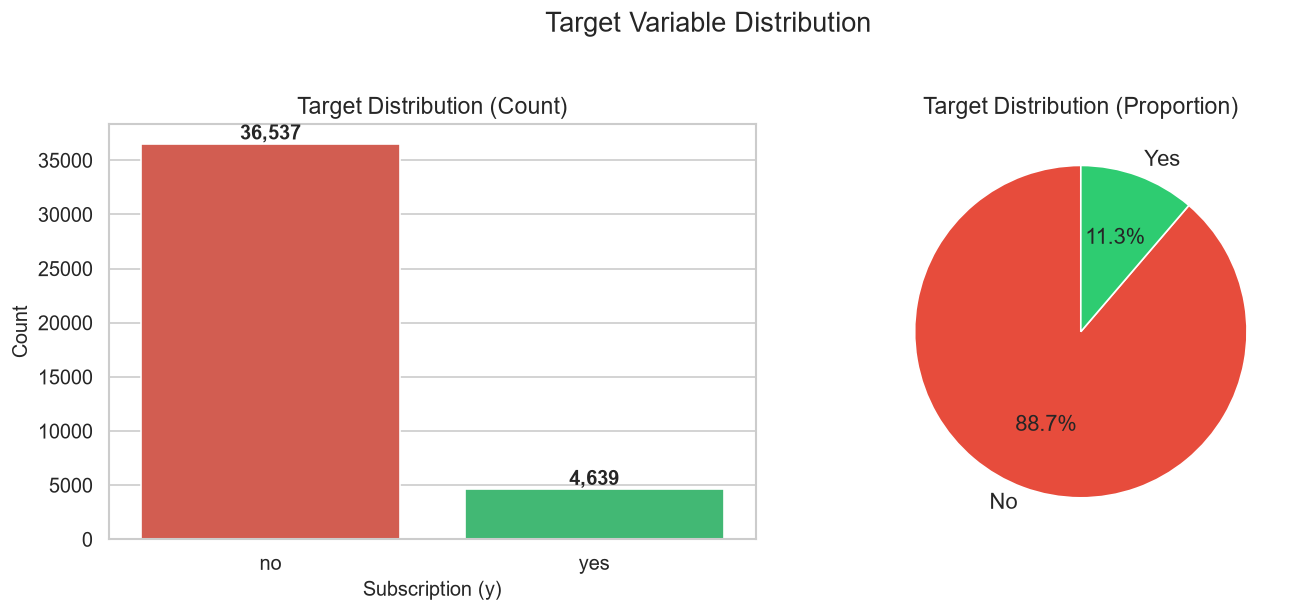

Target distribution:
y
no     36537
yes     4639
Name: count, dtype: int64

Proportions:
y
no     0.8873
yes    0.1127
Name: proportion, dtype: float64


In [11]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(data=df_clean, x="y", palette=["#e74c3c", "#2ecc71"], ax=axes[0])
axes[0].set_title("Target Distribution (Count)", fontsize=14)
axes[0].set_xlabel("Subscription (y)", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
target_counts = df_clean["y"].value_counts()
axes[1].pie(target_counts, labels=["No", "Yes"], autopct="%1.1f%%",
            colors=["#e74c3c", "#2ecc71"], startangle=90, textprops={"fontsize": 13})
axes[1].set_title("Target Distribution (Proportion)", fontsize=14)

fig.suptitle("Target Variable Distribution", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Print proportions
print("Target distribution:")
print(df_clean["y"].value_counts())
print(f"\nProportions:")
print(df_clean["y"].value_counts(normalize=True).round(4))

**Observation — Class Imbalance:**

The target variable is significantly imbalanced. The majority class (`no`) dominates with approximately 88.7% of all samples, while the minority class (`yes`) accounts for only ~11.3%.

**Implications:**
- Accuracy alone would be misleading (a model predicting all "no" would achieve ~88.7% accuracy).
- We must prioritize **F1-score** and **ROC-AUC** as primary evaluation metrics.
- Using `class_weight="balanced"` in classifiers helps address this imbalance.

### 4.2 Numerical Features Analysis

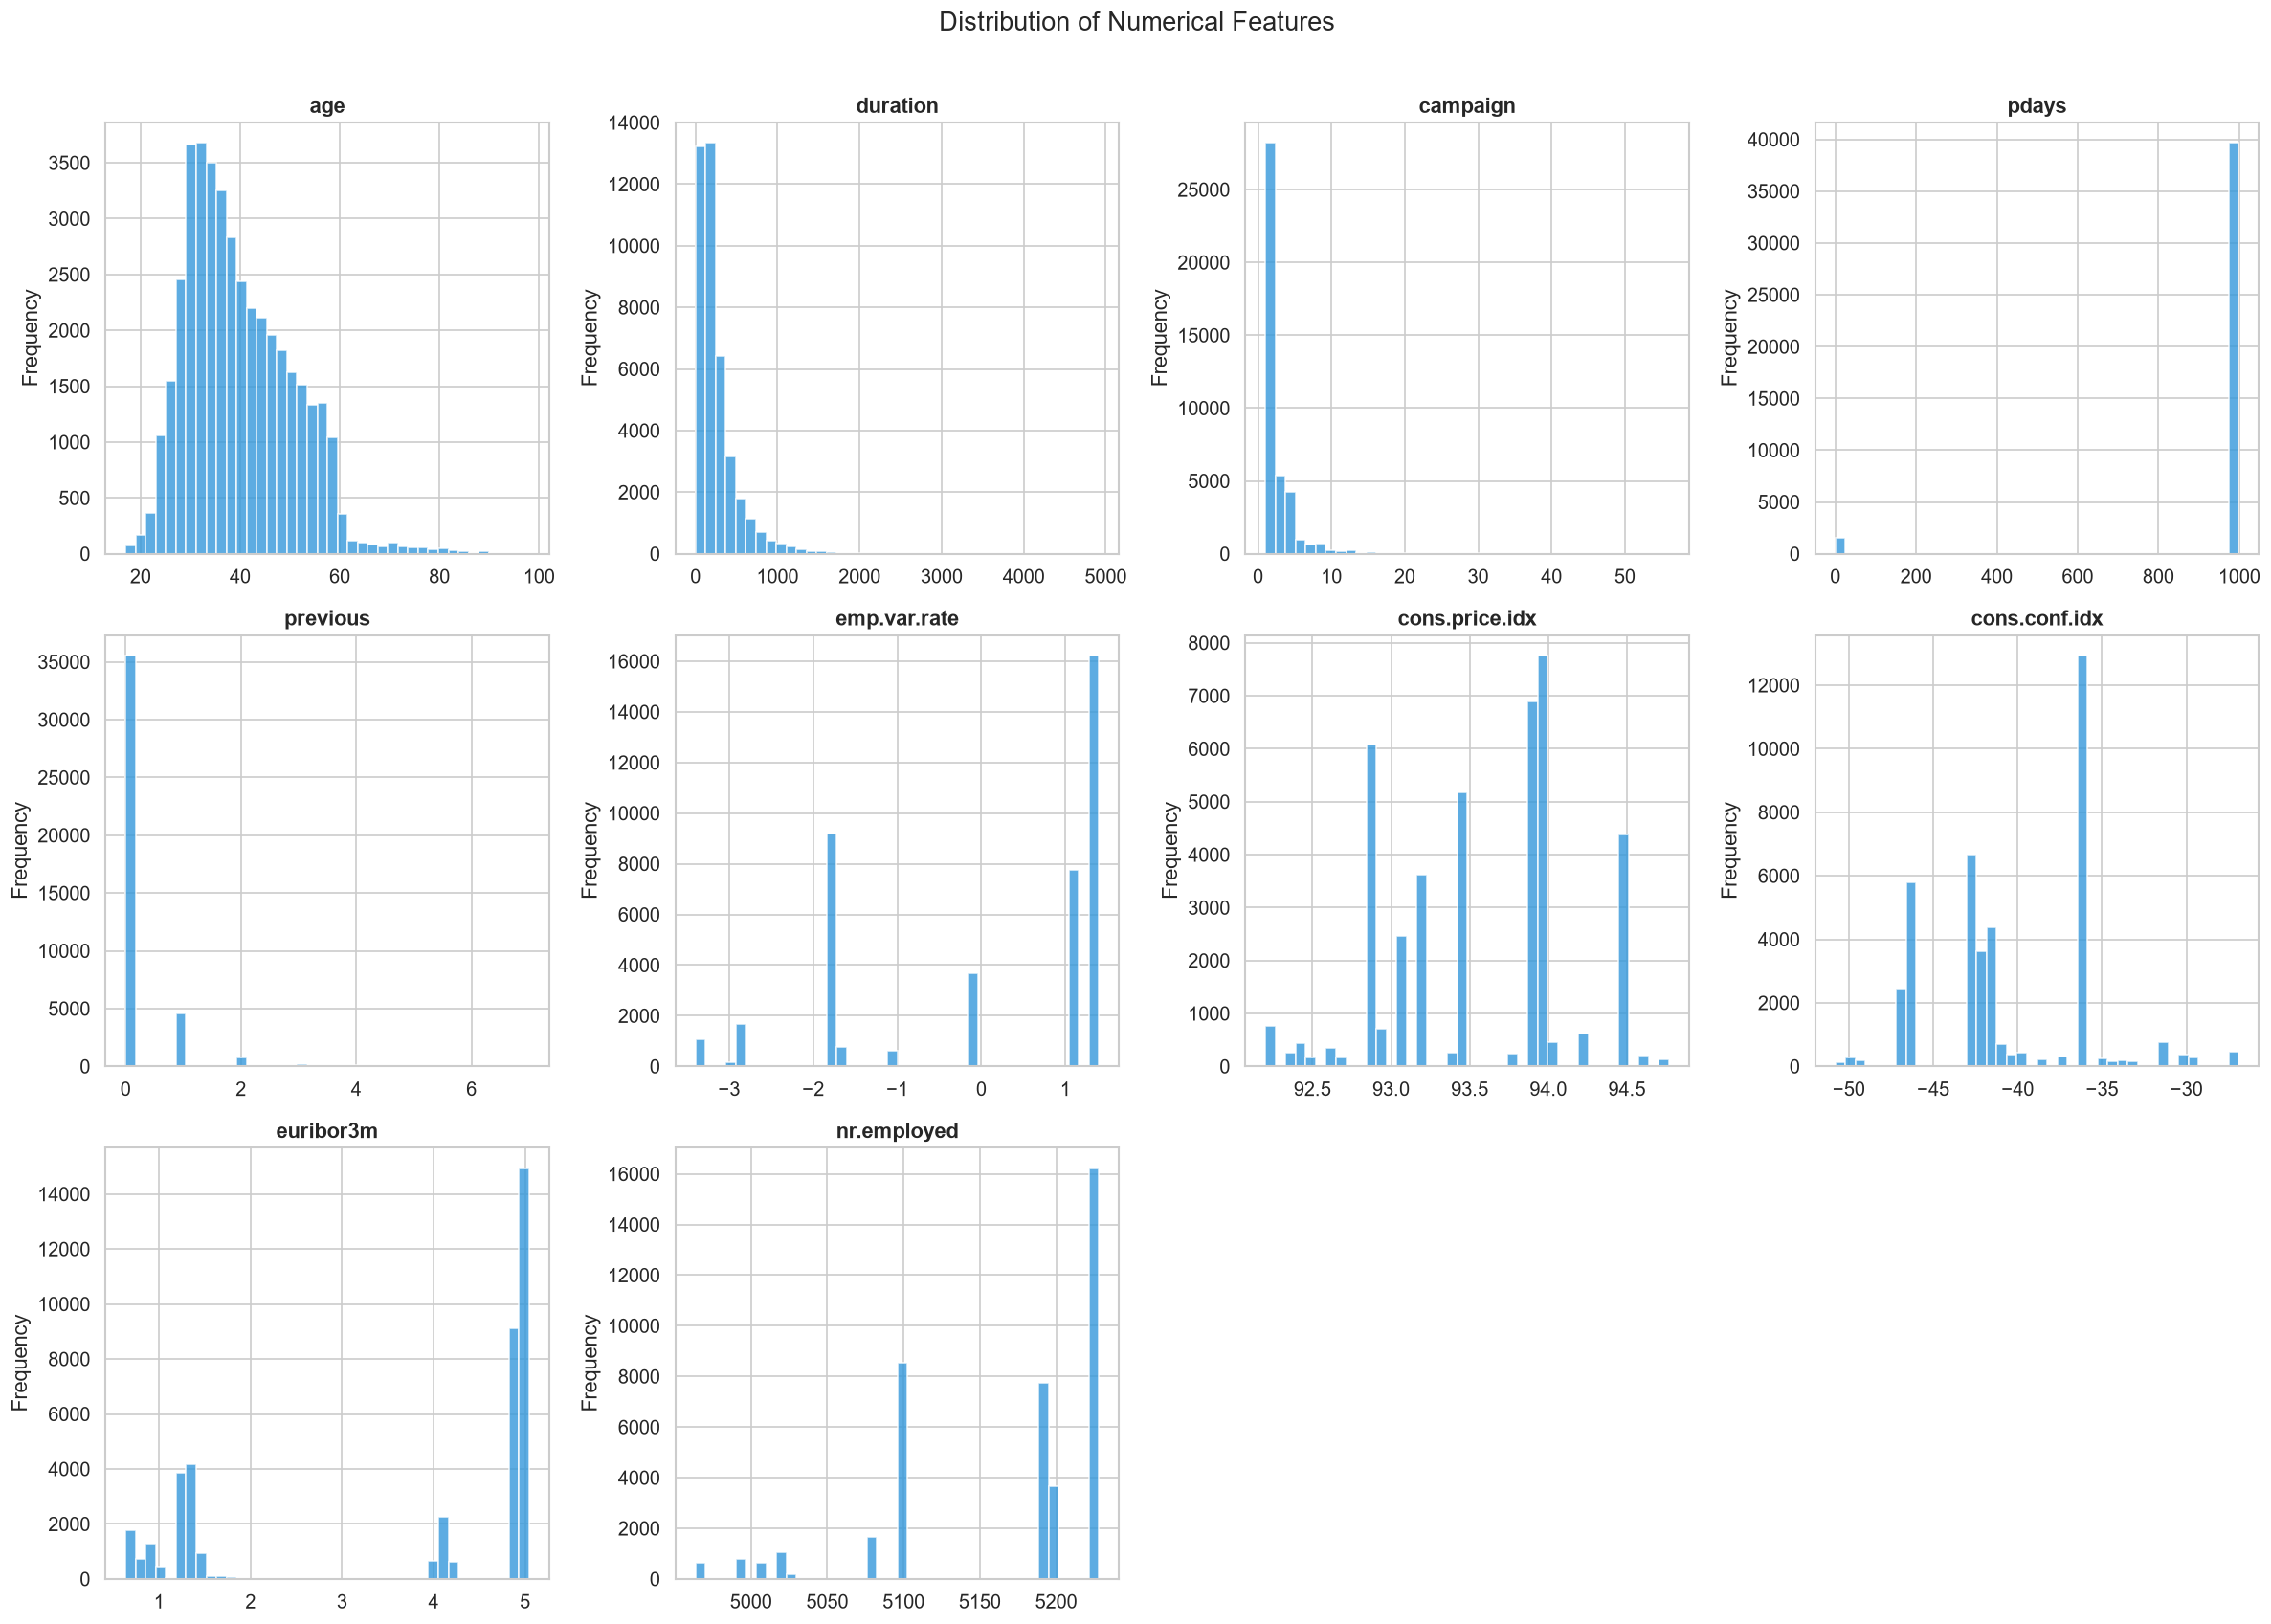

In [12]:
# Define numerical features
numerical_features = [
    "age", "duration", "campaign", "pdays", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx",
    "euribor3m", "nr.employed"
]

# Histograms for numerical features
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    ax = axes[i]
    df_clean[col].hist(bins=40, ax=ax, color="#3498db", edgecolor="white", alpha=0.8)
    ax.set_title(col, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

# Remove unused subplots
for j in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution of Numerical Features", fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_age_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

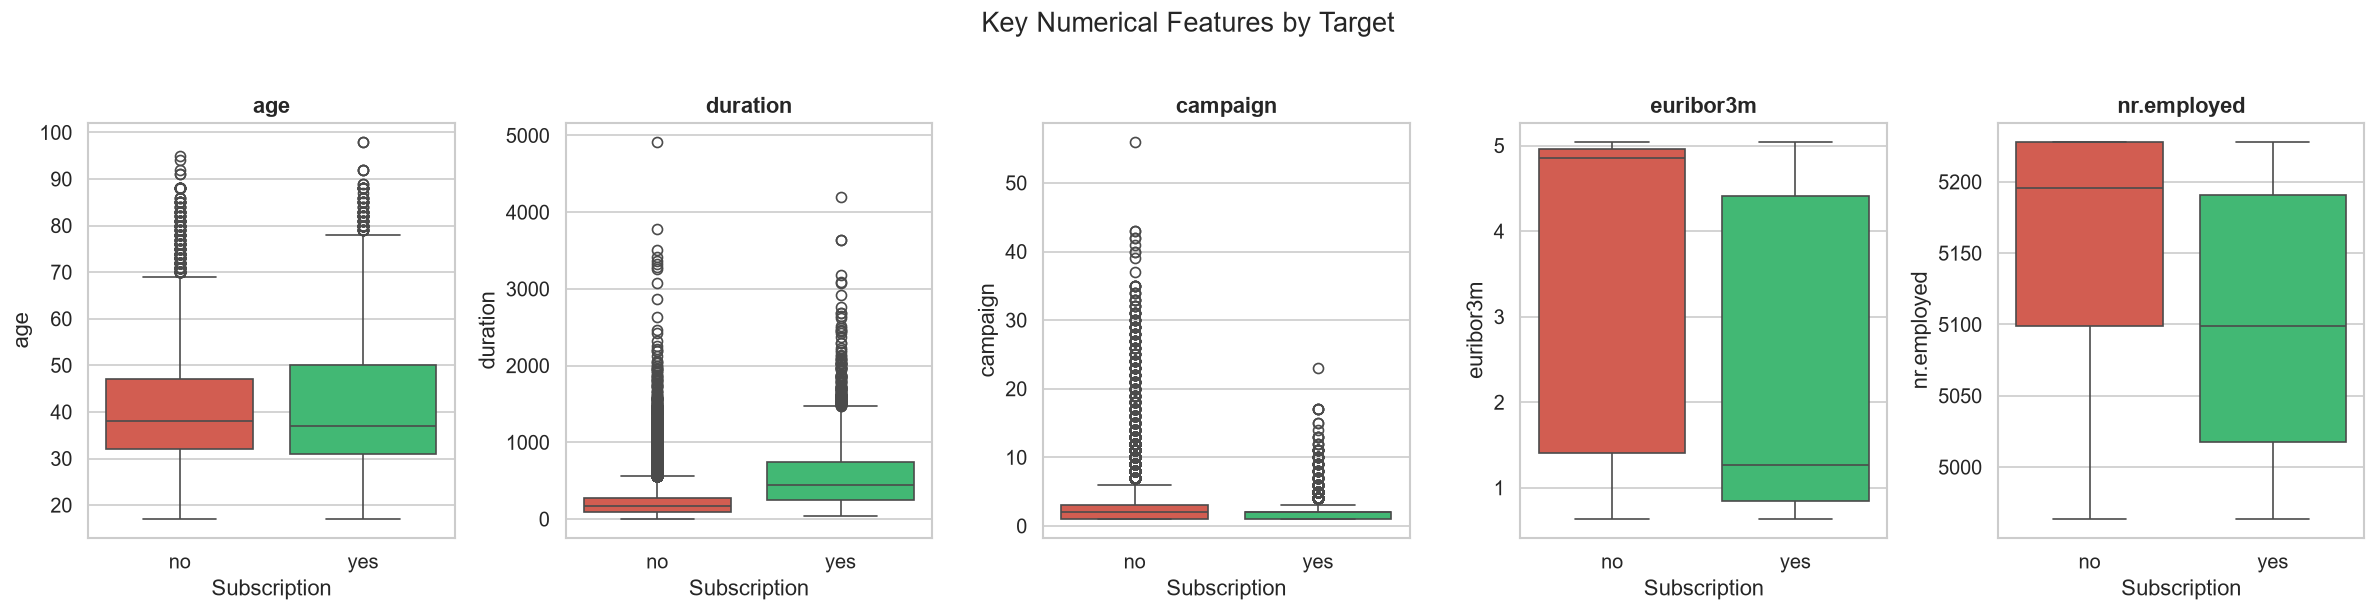

In [13]:
# Box plots by target for key numerical features
key_numerical = ["age", "duration", "campaign", "euribor3m", "nr.employed"]

fig, axes = plt.subplots(1, len(key_numerical), figsize=(20, 5))
for i, col in enumerate(key_numerical):
    sns.boxplot(data=df_clean, x="y", y=col, palette=["#e74c3c", "#2ecc71"], ax=axes[i])
    axes[i].set_title(col, fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Subscription")

fig.suptitle("Key Numerical Features by Target", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

### 4.3 Categorical Features Analysis

For categorical features, we compute **conversion rate** (proportion of `yes`) rather than just counts, as counts can be misleading when group sizes differ.

In [14]:
def plot_conversion_rate(df, feature, ax=None, top_n=None):
    """Plot conversion rate by a categorical feature."""
    temp = df[[feature, "y"]].copy()
    # Handle string target
    if temp["y"].dtype == "object":
        temp["y_num"] = temp["y"].map({"yes": 1, "no": 0})
    else:
        temp["y_num"] = temp["y"]
    conv = temp.groupby(feature)["y_num"].mean().sort_values(ascending=False)
    if top_n:
        conv = conv.head(top_n)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    
    bars = conv.plot(kind="bar", ax=ax, color="#3498db", edgecolor="white", alpha=0.85)
    ax.set_title(f"Conversion Rate by {feature}", fontsize=14, fontweight="bold")
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel("Conversion Rate", fontsize=12)
    ax.set_ylim(0, min(conv.max() * 1.3, 1.0))
    
    # Add value labels
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2%}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)
    
    ax.tick_params(axis='x', rotation=45)
    return ax

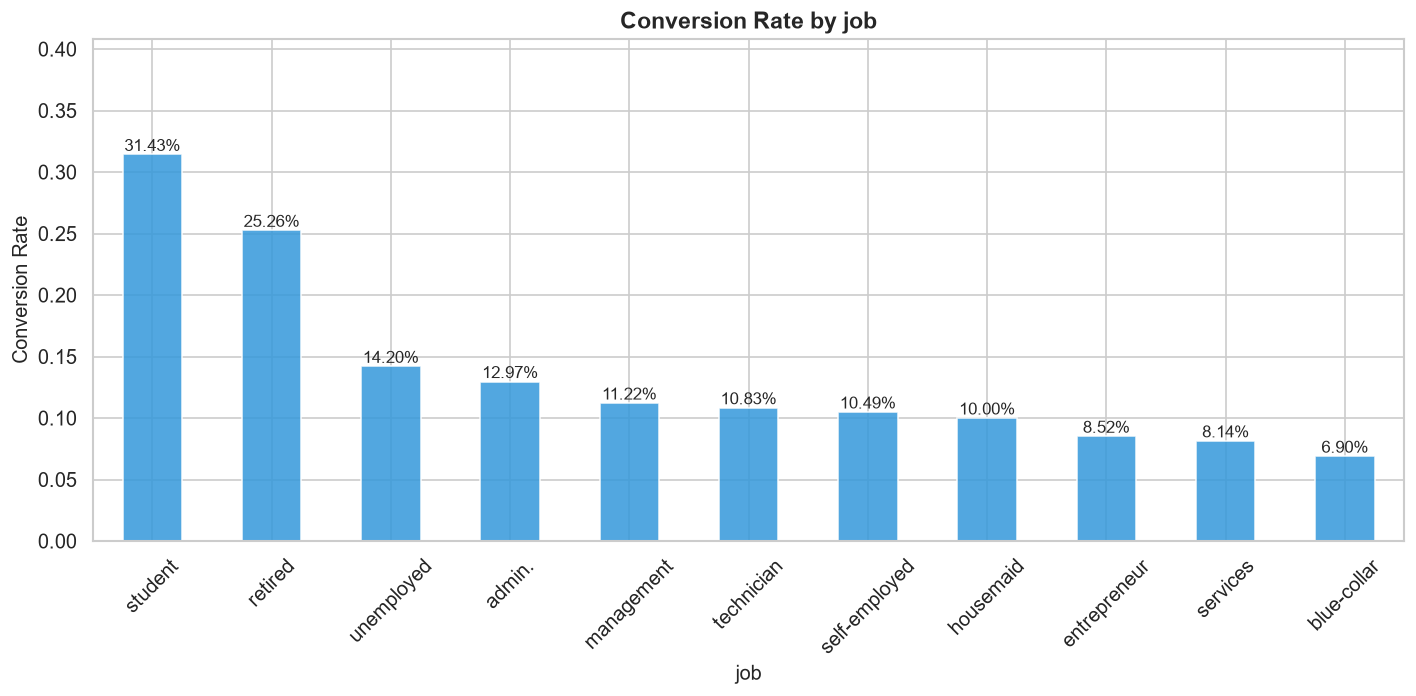

In [15]:
# Conversion rate by job
fig, ax = plt.subplots(figsize=(12, 6))
plot_conversion_rate(df_clean, "job", ax=ax)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_conversion_by_job.png", dpi=150, bbox_inches="tight")
plt.show()

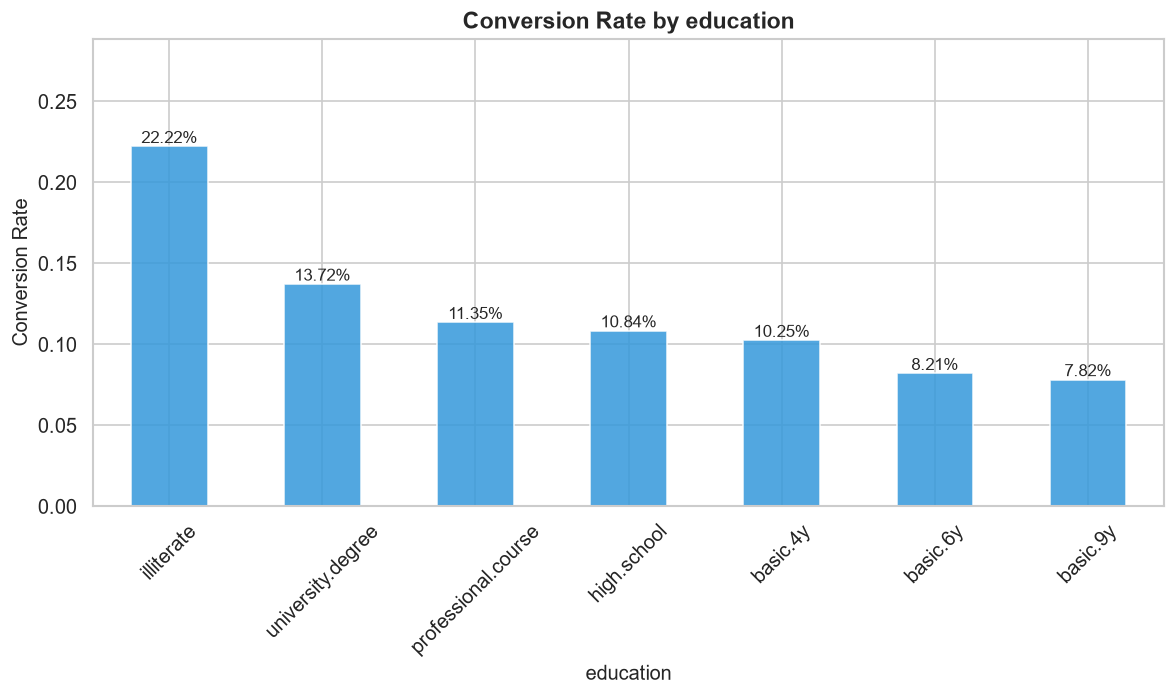

In [16]:
# Conversion rate by education
fig, ax = plt.subplots(figsize=(10, 6))
plot_conversion_rate(df_clean, "education", ax=ax)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_conversion_by_education.png", dpi=150, bbox_inches="tight")
plt.show()

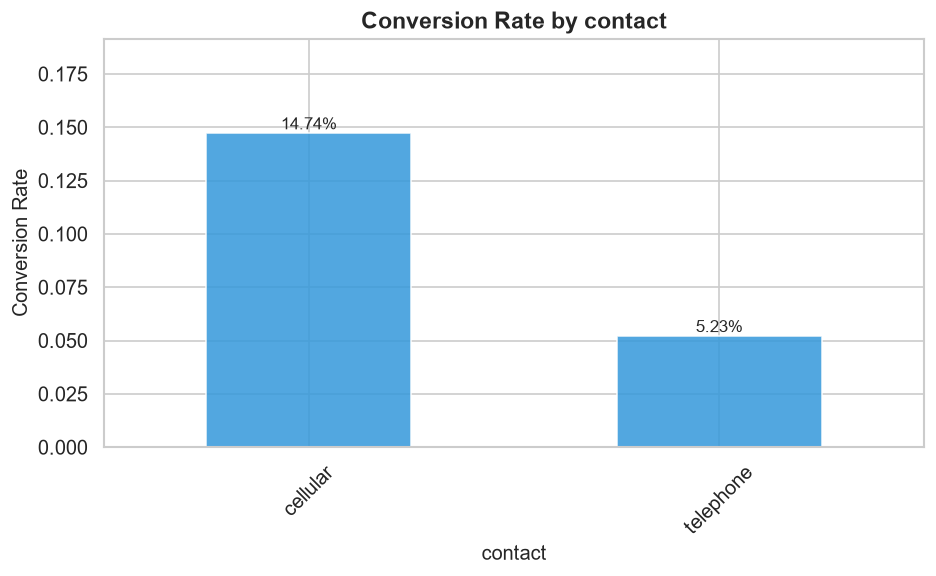

In [17]:
# Conversion rate by contact type
fig, ax = plt.subplots(figsize=(8, 5))
plot_conversion_rate(df_clean, "contact", ax=ax)
fig.tight_layout()
plt.show()

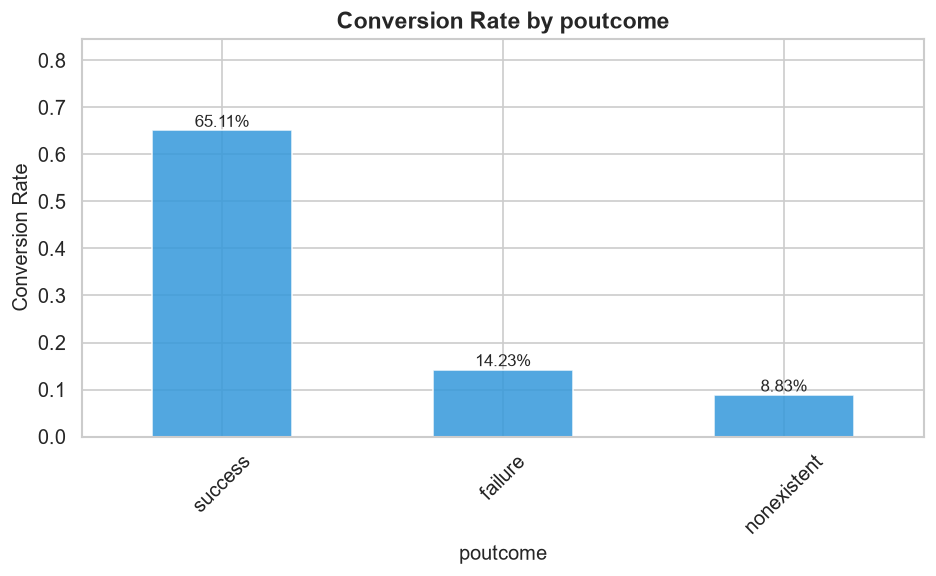

In [18]:
# Conversion rate by previous outcome — very important feature!
fig, ax = plt.subplots(figsize=(8, 5))
plot_conversion_rate(df_clean, "poutcome", ax=ax)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_conversion_by_poutcome.png", dpi=150, bbox_inches="tight")
plt.show()

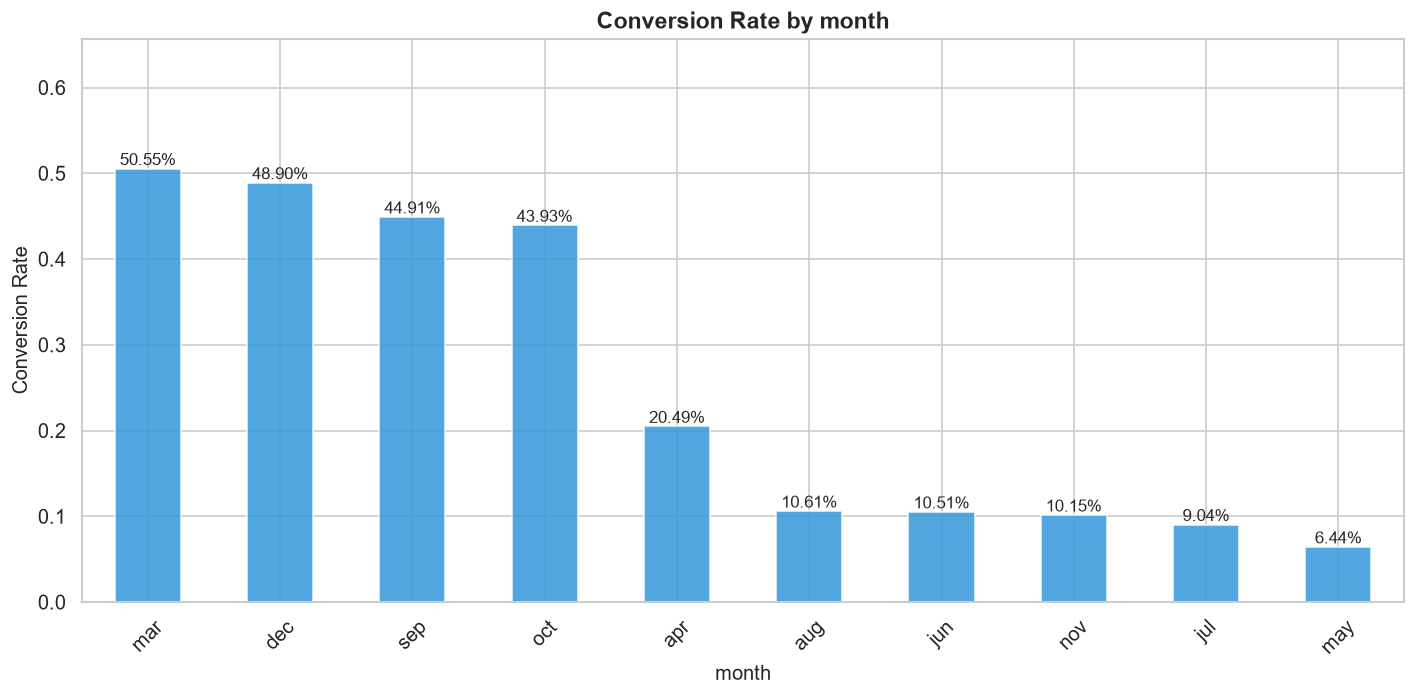

In [19]:
# Conversion rate by month
fig, ax = plt.subplots(figsize=(12, 6))
plot_conversion_rate(df_clean, "month", ax=ax)
fig.tight_layout()
plt.show()

**Key EDA Observations:**

1. **`poutcome` (Previous campaign outcome):** Customers who previously had a "success" outcome show dramatically higher conversion rates (~65%) compared to "failure" or "nonexistent". This is a powerful predictor.

2. **`contact` method:** Cellular contact shows a higher conversion rate than telephone.

3. **`job`:** Students and retirees tend to have higher conversion rates, while blue-collar workers have lower rates.

4. **`month`:** March, December, September, and October show higher conversion rates — potentially linked to seasonal marketing effectiveness.

5. **`duration`:** Longer call duration correlates with higher conversion — but this is known only after the call, so it cannot be used for pre-call targeting in practice.

### 4.4 Correlation Analysis (Numerical Features Only)

We compute correlations only for numerical features. Computing correlation on one-hot encoded categoricals would be misleading and inflate the heatmap.

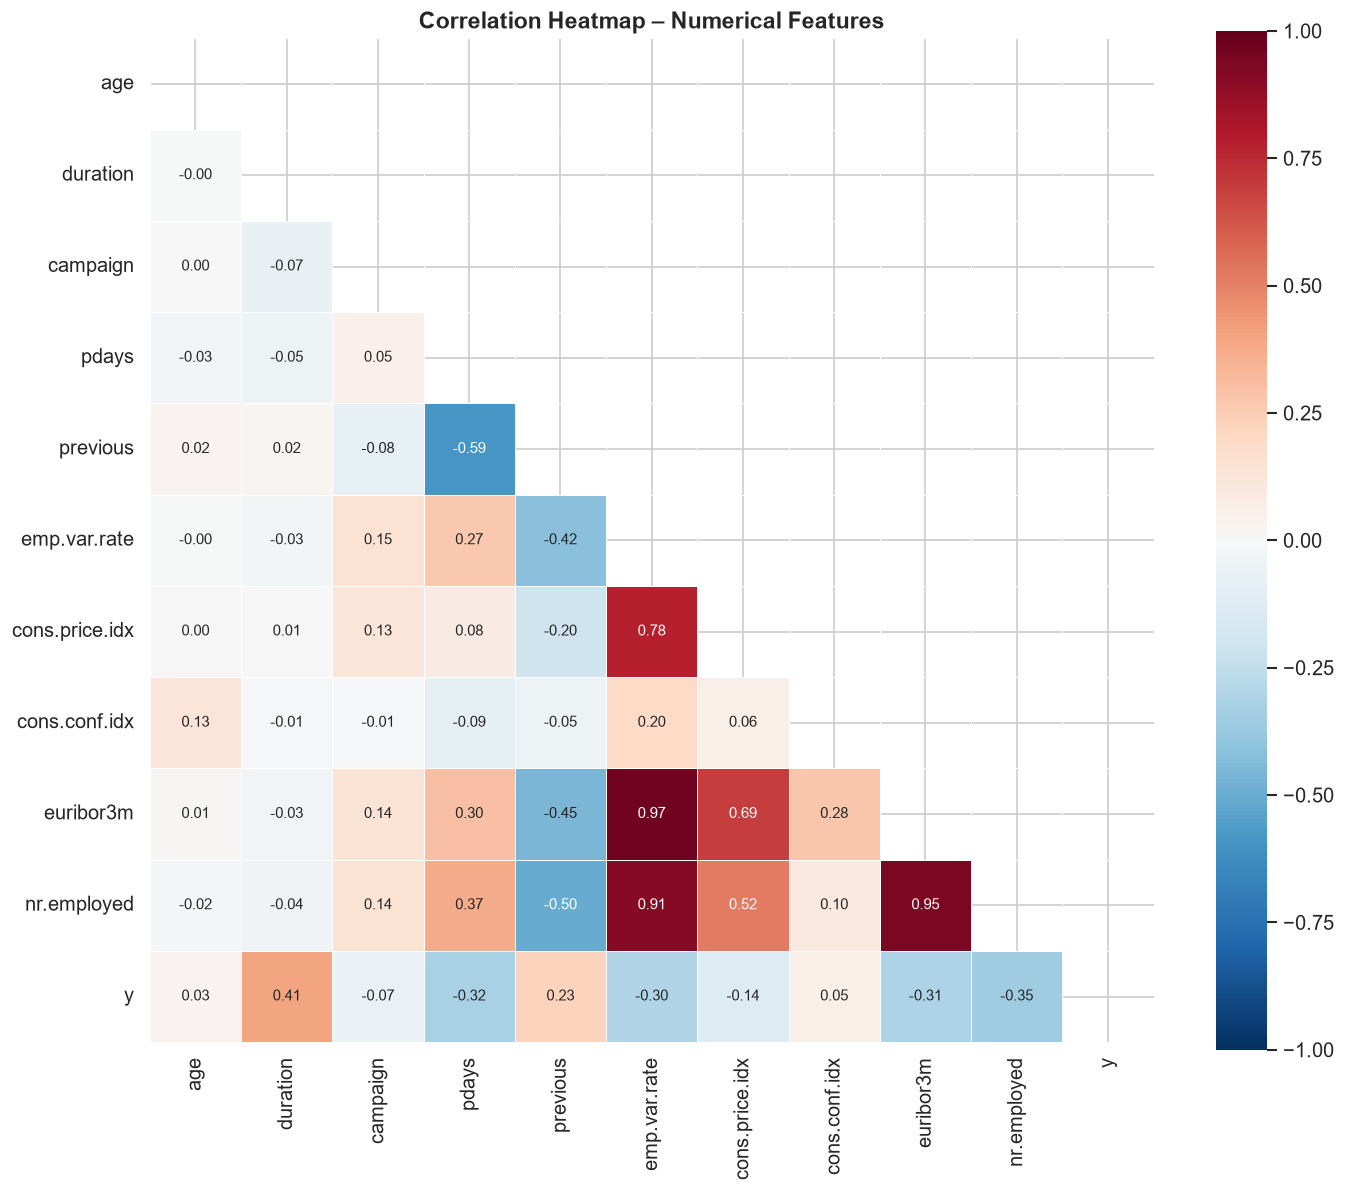


Correlation with target (y):
duration          0.4053
previous          0.2302
cons.conf.idx     0.0548
age               0.0304
campaign         -0.0664
cons.price.idx   -0.1361
emp.var.rate     -0.2983
euribor3m        -0.3077
pdays            -0.3249
nr.employed      -0.3547
Name: y, dtype: float64


In [20]:
# Correlation heatmap for numerical features
# Temporarily encode target for correlation analysis
df_corr = df_clean[numerical_features + ["y"]].copy()
df_corr["y"] = df_corr["y"].map({"yes": 1, "no": 0}) if df_corr["y"].dtype == "object" else df_corr["y"]

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={"size": 9}
)
ax.set_title("Correlation Heatmap – Numerical Features", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCorrelation with target (y):")
print(corr_matrix["y"].drop("y").sort_values(ascending=False).round(4))

**Correlation Observations:**

- `euribor3m`, `emp.var.rate`, and `nr.employed` are highly correlated with each other — they all represent macroeconomic conditions.
- `duration` shows the strongest positive correlation with the target, but it is only known after the contact.
- `pdays` and `previous` capture prior campaign contact history.
- Multicollinearity among economic indicators is noted but handled naturally by tree-based models.

## Part 5 – Feature Engineering

We create meaningful features based on business logic. Each new feature should have a clear interpretation.

In [21]:
# 1. Has Previous Contact — binary indicator
# Business meaning: Whether the customer was contacted in a prior campaign
df_clean["has_previous_contact"] = (df_clean["previous"] > 0).astype(int)
print("has_previous_contact distribution:")
print(df_clean["has_previous_contact"].value_counts())
print(f"\nConversion rate with previous contact: "
      f"{df_clean[df_clean['has_previous_contact']==1]['y'].map({'yes':1,'no':0}).mean() if df_clean['y'].dtype=='object' else df_clean[df_clean['has_previous_contact']==1]['y'].mean():.2%}")
print(f"Conversion rate without previous contact: "
      f"{df_clean[df_clean['has_previous_contact']==0]['y'].map({'yes':1,'no':0}).mean() if df_clean['y'].dtype=='object' else df_clean[df_clean['has_previous_contact']==0]['y'].mean():.2%}")

has_previous_contact distribution:
has_previous_contact
0    35551
1     5625
Name: count, dtype: int64

Conversion rate with previous contact: 26.65%
Conversion rate without previous contact: 8.83%


In [22]:
# 2. Campaign Intensity — bucketed campaign contacts
# Business meaning: Intensity level of contacts during this campaign
df_clean["campaign_intensity"] = pd.cut(
    df_clean["campaign"],
    bins=[0, 1, 3, 5, np.inf],
    labels=["single", "low", "medium", "high"]
)
print("\ncampaign_intensity distribution:")
print(df_clean["campaign_intensity"].value_counts())


campaign_intensity distribution:
campaign_intensity
single    17634
low       15908
medium     4249
high       3385
Name: count, dtype: int64


In [23]:
# 3. Age Group — demographic segmentation
# Business meaning: Different age groups may respond differently to campaigns
df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[0, 30, 40, 55, np.inf],
    labels=["young", "adult", "middle_age", "senior"]
)
print("\nage_group distribution:")
print(df_clean["age_group"].value_counts())


age_group distribution:
age_group
adult         16380
middle_age    13834
young          7381
senior         3581
Name: count, dtype: int64


**Feature Engineering Rationale:**

1. **`has_previous_contact`:** Simplifies `previous` into a binary signal. Prior contact history is a strong indicator of customer engagement level.

2. **`campaign_intensity`:** Groups the number of contacts into meaningful business buckets. Too many contacts may indicate "hard-to-convert" customers.

3. **`age_group`:** Segments customers into demographic groups for easier interpretation. Different life stages correlate with different financial product needs.

## Part 6 – Target Encoding & Feature/Target Split

In [24]:
# Encode target: yes → 1, no → 0
if df_clean["y"].dtype == "object":
    df_clean["y"] = df_clean["y"].map({"yes": 1, "no": 0})

print("Target encoding:")
print(df_clean["y"].value_counts())
print(f"\nPositive rate: {df_clean['y'].mean():.2%}")

Target encoding:
y
0    36537
1     4639
Name: count, dtype: int64

Positive rate: 11.27%


In [25]:
# Define feature lists
NUMERIC_FEATURES = [
    "age", "duration", "campaign", "pdays", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx",
    "euribor3m", "nr.employed",
    "has_previous_contact",  # engineered numeric feature
]

CATEGORICAL_FEATURES = [
    "job", "marital", "education", "default", "housing",
    "loan", "contact", "month", "day_of_week", "poutcome",
    "campaign_intensity", "age_group",  # engineered categorical features
]

# Separate features and target
X = df_clean[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df_clean["y"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nNumeric features ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"Categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")

Features shape: (41176, 23)
Target shape: (41176,)

Numeric features (11): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'has_previous_contact']
Categorical features (12): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'campaign_intensity', 'age_group']


## Part 7 – Train/Test Split

We use `stratify=y` to ensure the same class distribution in both train and test sets, which is critical for imbalanced datasets.

**Important:** All preprocessing is done via Pipeline/ColumnTransformer — fit only on training data to prevent data leakage.

In [26]:
# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))
print(f"\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training set: 28823 samples (70.0%)
Test set:     12353 samples (30.0%)

Training target distribution:
y
0    0.8873
1    0.1127
Name: proportion, dtype: float64

Test target distribution:
y
0    0.8873
1    0.1127
Name: proportion, dtype: float64


## Part 8 – Preprocessing Pipeline

Using `ColumnTransformer` + `Pipeline` ensures:
- No data leakage (fit only on train, transform on test)
- Reproducibility
- Clean and modular code

In [27]:
# Build preprocessing pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)

print("Preprocessing pipeline created successfully.")
print(f"  - Numeric: {len(NUMERIC_FEATURES)} features → Imputer(median) + StandardScaler")
print(f"  - Categorical: {len(CATEGORICAL_FEATURES)} features → Imputer(most_frequent) + OneHotEncoder")

Preprocessing pipeline created successfully.
  - Numeric: 11 features → Imputer(median) + StandardScaler
  - Categorical: 12 features → Imputer(most_frequent) + OneHotEncoder


## Part 9 – Define & Train Models (4 Algorithms)

We train 4 classification models:
1. **Logistic Regression** — linear baseline with balanced class weights
2. **Decision Tree** — interpretable tree model
3. **Random Forest** — ensemble of decision trees
4. **Gradient Boosting** — sequential boosting approach

In [28]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42,
    ),
}

# Create pipelines (preprocessor + model)
pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model),
    ])

print("Pipelines created:")
for name in pipelines:
    print(f"  ✓ {name}")

Pipelines created:
  ✓ Logistic Regression
  ✓ Decision Tree
  ✓ Random Forest
  ✓ Gradient Boosting


## Part 10 – Stratified K-Fold Cross-Validation

Using 5-fold Stratified Cross-Validation on the **training set only** to get robust performance estimates.

We prioritize **F1** and **ROC-AUC** over accuracy due to class imbalance.

In [29]:
# Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results_list = []

for name, pipe in pipelines.items():
    print(f"Cross-validating {name}...", end=" ")
    cv_res = cross_validate(
        pipe, X_train, y_train,
        cv=skf, scoring=scoring, n_jobs=-1,
    )
    cv_results_list.append({
        "Model": name,
        "CV Accuracy": cv_res["test_accuracy"].mean(),
        "CV Precision": cv_res["test_precision"].mean(),
        "CV Recall": cv_res["test_recall"].mean(),
        "CV F1": cv_res["test_f1"].mean(),
        "CV ROC-AUC": cv_res["test_roc_auc"].mean(),
    })
    print(f"done (F1={cv_res['test_f1'].mean():.4f}, AUC={cv_res['test_roc_auc'].mean():.4f})")

cv_results_df = pd.DataFrame(cv_results_list)
cv_results_df = cv_results_df.round(4)
print("\n" + "="*80)
print("CROSS-VALIDATION RESULTS")
print("="*80)
cv_results_df

Cross-validating Logistic Regression... 

done (F1=0.5876, AUC=0.9371)
Cross-validating Decision Tree... 

done (F1=0.5067, AUC=0.7187)
Cross-validating Random Forest... 

done (F1=0.6315, AUC=0.9449)
Cross-validating Gradient Boosting... 

done (F1=0.5804, AUC=0.9466)

CROSS-VALIDATION RESULTS


,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Logistic Regression,0.8604,0.4404,0.8827,0.5876,0.9371
1,Decision Tree,0.8911,0.5179,0.4962,0.5067,0.7187
2,Random Forest,0.9064,0.5677,0.7114,0.6315,0.9449
3,Gradient Boosting,0.9158,0.6613,0.5174,0.5804,0.9466


## Part 11 – Final Test Set Evaluation

Now we fit each model on the **entire training set** and evaluate on the held-out **test set**. These are the final, unbiased performance estimates.

In [30]:
# Fit on full training set and evaluate on test set
test_results_list = []
fitted_pipelines = {}

for name, pipe in pipelines.items():
    print(f"Training and evaluating {name}...", end=" ")
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    
    test_results_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })
    fitted_pipelines[name] = pipe
    print("done")

test_results_df = pd.DataFrame(test_results_list)
test_results_df = test_results_df.round(4)
print("\n" + "="*80)
print("TEST SET RESULTS")
print("="*80)
test_results_df

Training and evaluating Logistic Regression... 

done
Training and evaluating Decision Tree... 

done
Training and evaluating Random Forest... 

done
Training and evaluating Gradient Boosting... 

done

TEST SET RESULTS


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8642,0.4484,0.8937,0.5972,0.9383
1,Decision Tree,0.8901,0.5129,0.4871,0.4996,0.7142
2,Random Forest,0.9063,0.5669,0.7119,0.6312,0.9430
3,Gradient Boosting,0.9169,0.6583,0.5453,0.5965,0.9472


In [31]:
# Save results to CSV
cv_results_df.to_csv(RESULTS_DIR / "cv_results.csv", index=False)
test_results_df.to_csv(RESULTS_DIR / "test_results.csv", index=False)
print("Results saved to outputs/results/")

Results saved to outputs/results/


## Part 12 – Confusion Matrices

Confusion matrices show the breakdown of predictions into:
- **True Positive (TP):** Correctly predicted YES
- **True Negative (TN):** Correctly predicted NO
- **False Positive (FP):** Predicted YES but actually NO (wasted marketing resources)
- **False Negative (FN):** Predicted NO but actually YES (missed opportunity)

**Business Impact of False Negatives:** The model predicts a customer will not respond positively, but they would have subscribed. This means the business misses a potential conversion — a lost revenue opportunity. In marketing, FN is often more costly than FP.

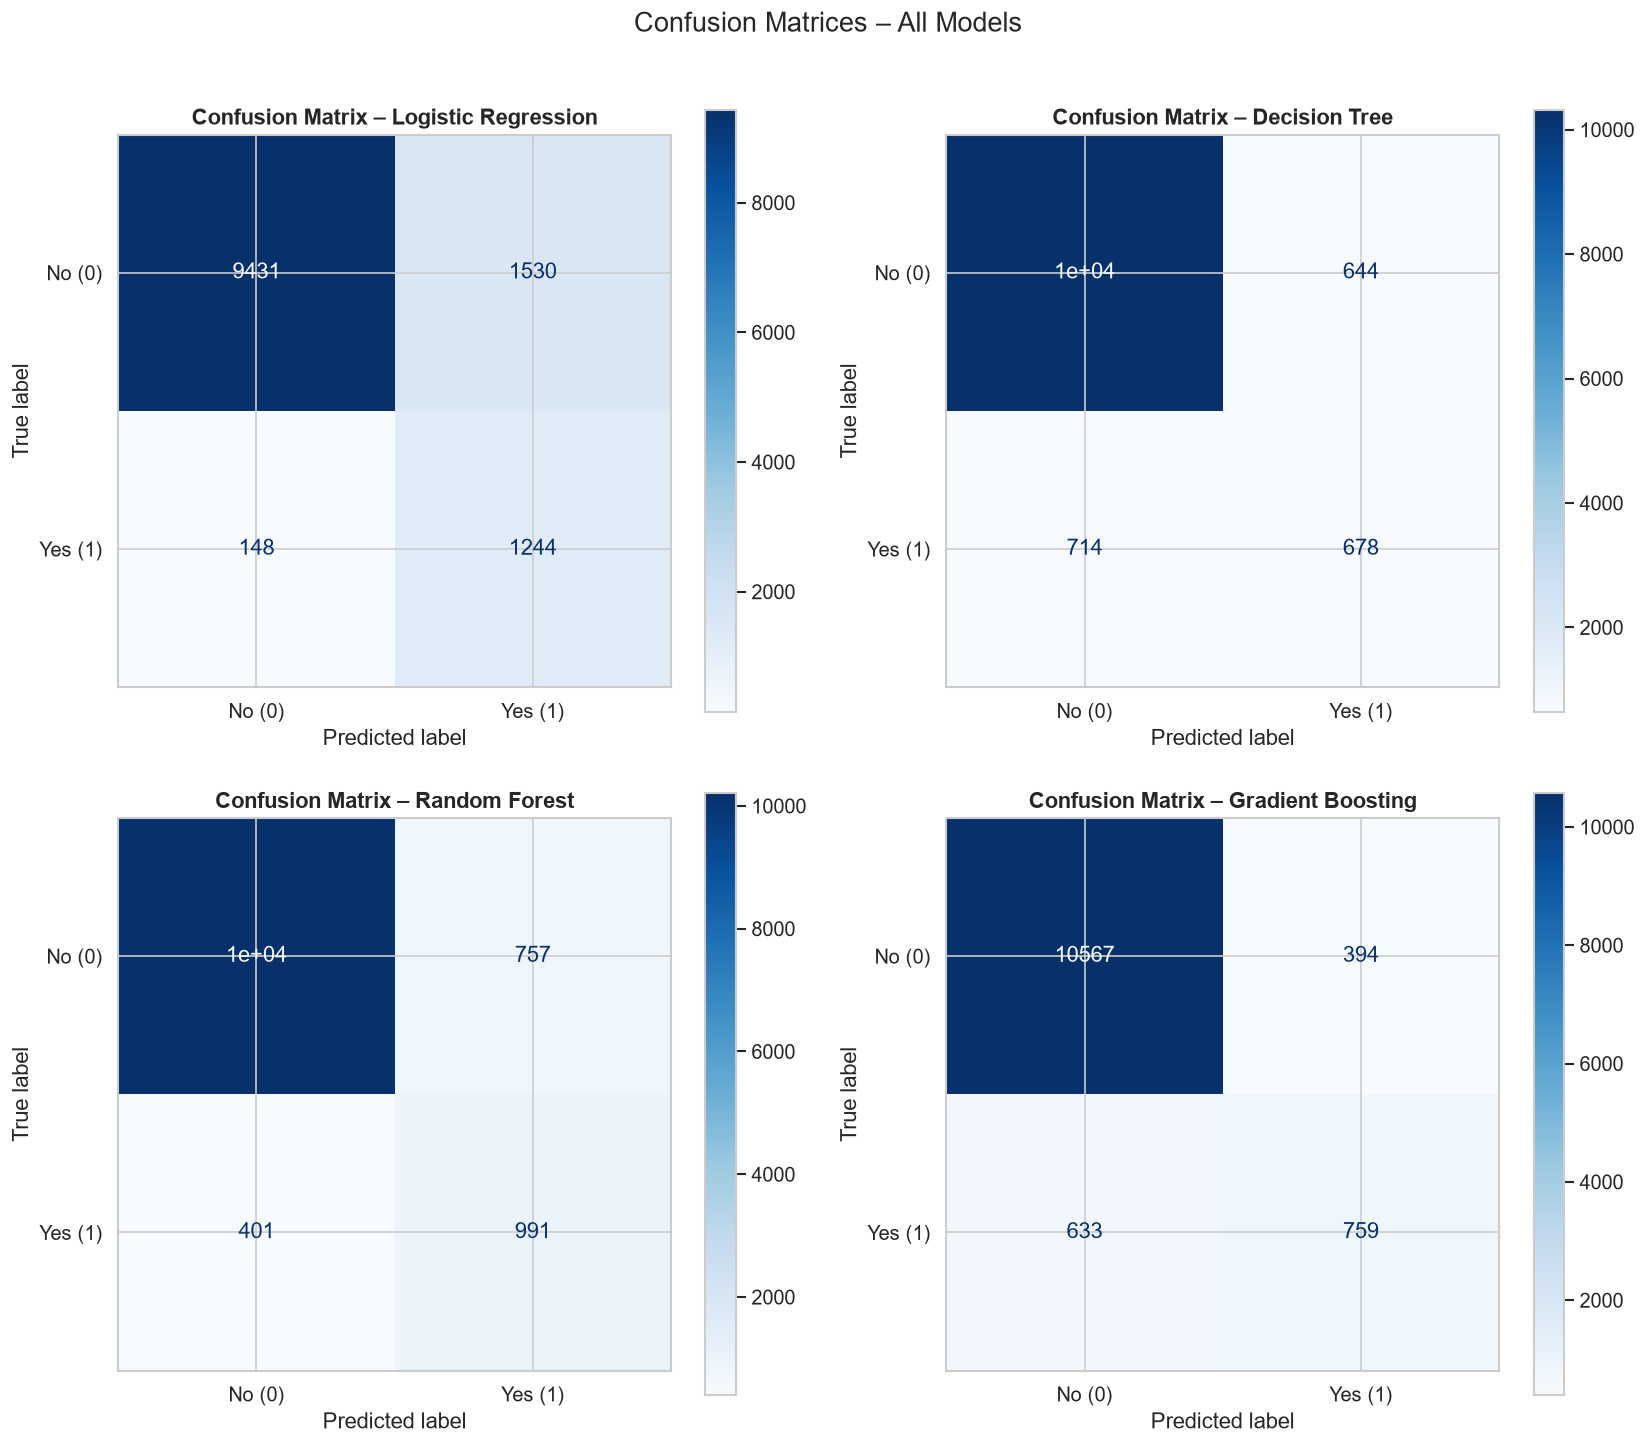

In [32]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (name, pipe) in enumerate(fitted_pipelines.items()):
    y_pred = pipe.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["No (0)", "Yes (1)"],
        cmap="Blues", ax=axes[i],
    )
    axes[i].set_title(f"Confusion Matrix – {name}", fontsize=13, fontweight="bold")

fig.suptitle("Confusion Matrices – All Models", fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "08_confusion_matrix_all.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
# Also save individual confusion matrices
for name, pipe in fitted_pipelines.items():
    y_pred = pipe.predict(X_test)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["No (0)", "Yes (1)"],
        cmap="Blues", ax=ax,
    )
    ax.set_title(f"Confusion Matrix – {name}", fontsize=13, fontweight="bold")
    fig.tight_layout()
    safe_name = name.lower().replace(" ", "_")
    fig.savefig(FIGURES_DIR / f"08_confusion_matrix_{safe_name}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    
print("Individual confusion matrices saved.")

Individual confusion matrices saved.


### Interpretation of Confusion Matrix Errors

**False Negative (FN) in this marketing context:**
> The model predicts a customer will NOT respond positively, but in reality, the customer WOULD have subscribed to the product. This is a **missed opportunity** — the marketing team does not target this customer, and the potential revenue is lost.

**False Positive (FP) in this marketing context:**
> The model predicts a customer WILL respond positively, but the customer does NOT subscribe. This results in **wasted marketing resources** (time spent on a call, cost of sending a promotion, etc.).

**Business trade-off:** In most marketing scenarios, FN is more costly because acquiring a customer is valuable. Therefore, we often prefer models with higher **Recall** (fewer FN), even at the cost of some Precision (more FP).

## Part 13 – ROC Curve Comparison

The **ROC curve** plots the True Positive Rate vs False Positive Rate at various classification thresholds.

**ROC-AUC (Area Under the Curve):**
- 1.0 = Perfect model
- 0.5 = Random classifier (no better than chance)
- Higher AUC = better ability to distinguish between classes

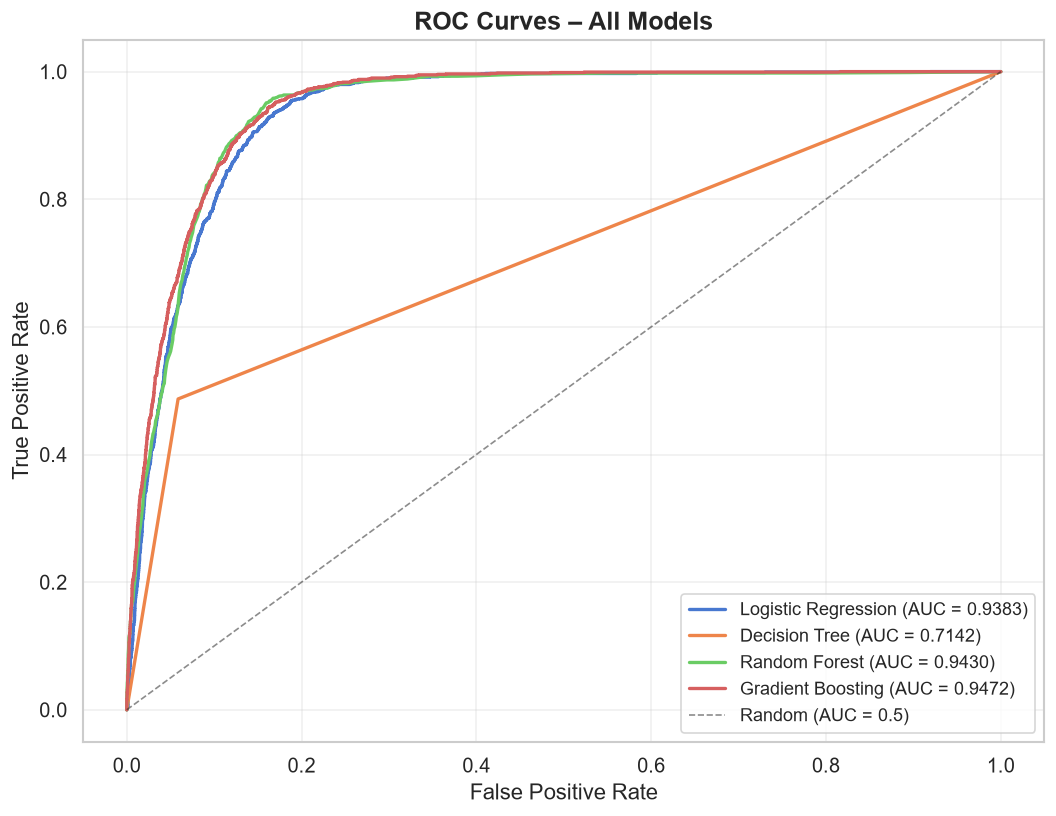

In [34]:
# Plot ROC curves for all models on the same figure
fig, ax = plt.subplots(figsize=(9, 7))

for name, pipe in fitted_pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.5, linewidth=1, label="Random (AUC = 0.5)")
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title("ROC Curves – All Models", fontsize=15, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "09_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 14 – Feature Importance

We extract feature importance from tree-based models (`feature_importances_`) and coefficient magnitude from Logistic Regression (`coef_`).

Since categorical features are one-hot encoded, we need to retrieve the correct feature names from the fitted `ColumnTransformer`.

In [35]:
# Get feature names after preprocessing
def get_feature_names(pipeline):
    """Extract feature names from a fitted pipeline's preprocessor."""
    preprocessor = pipeline.named_steps["preprocessor"]
    
    # Numeric features keep their names
    num_features = list(NUMERIC_FEATURES)
    
    # Categorical features are one-hot encoded
    ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_features = list(ohe.get_feature_names_out(CATEGORICAL_FEATURES))
    
    return num_features + cat_features

# Get feature names from any fitted pipeline
feature_names = get_feature_names(list(fitted_pipelines.values())[0])
print(f"Total features after preprocessing: {len(feature_names)}")

Total features after preprocessing: 67


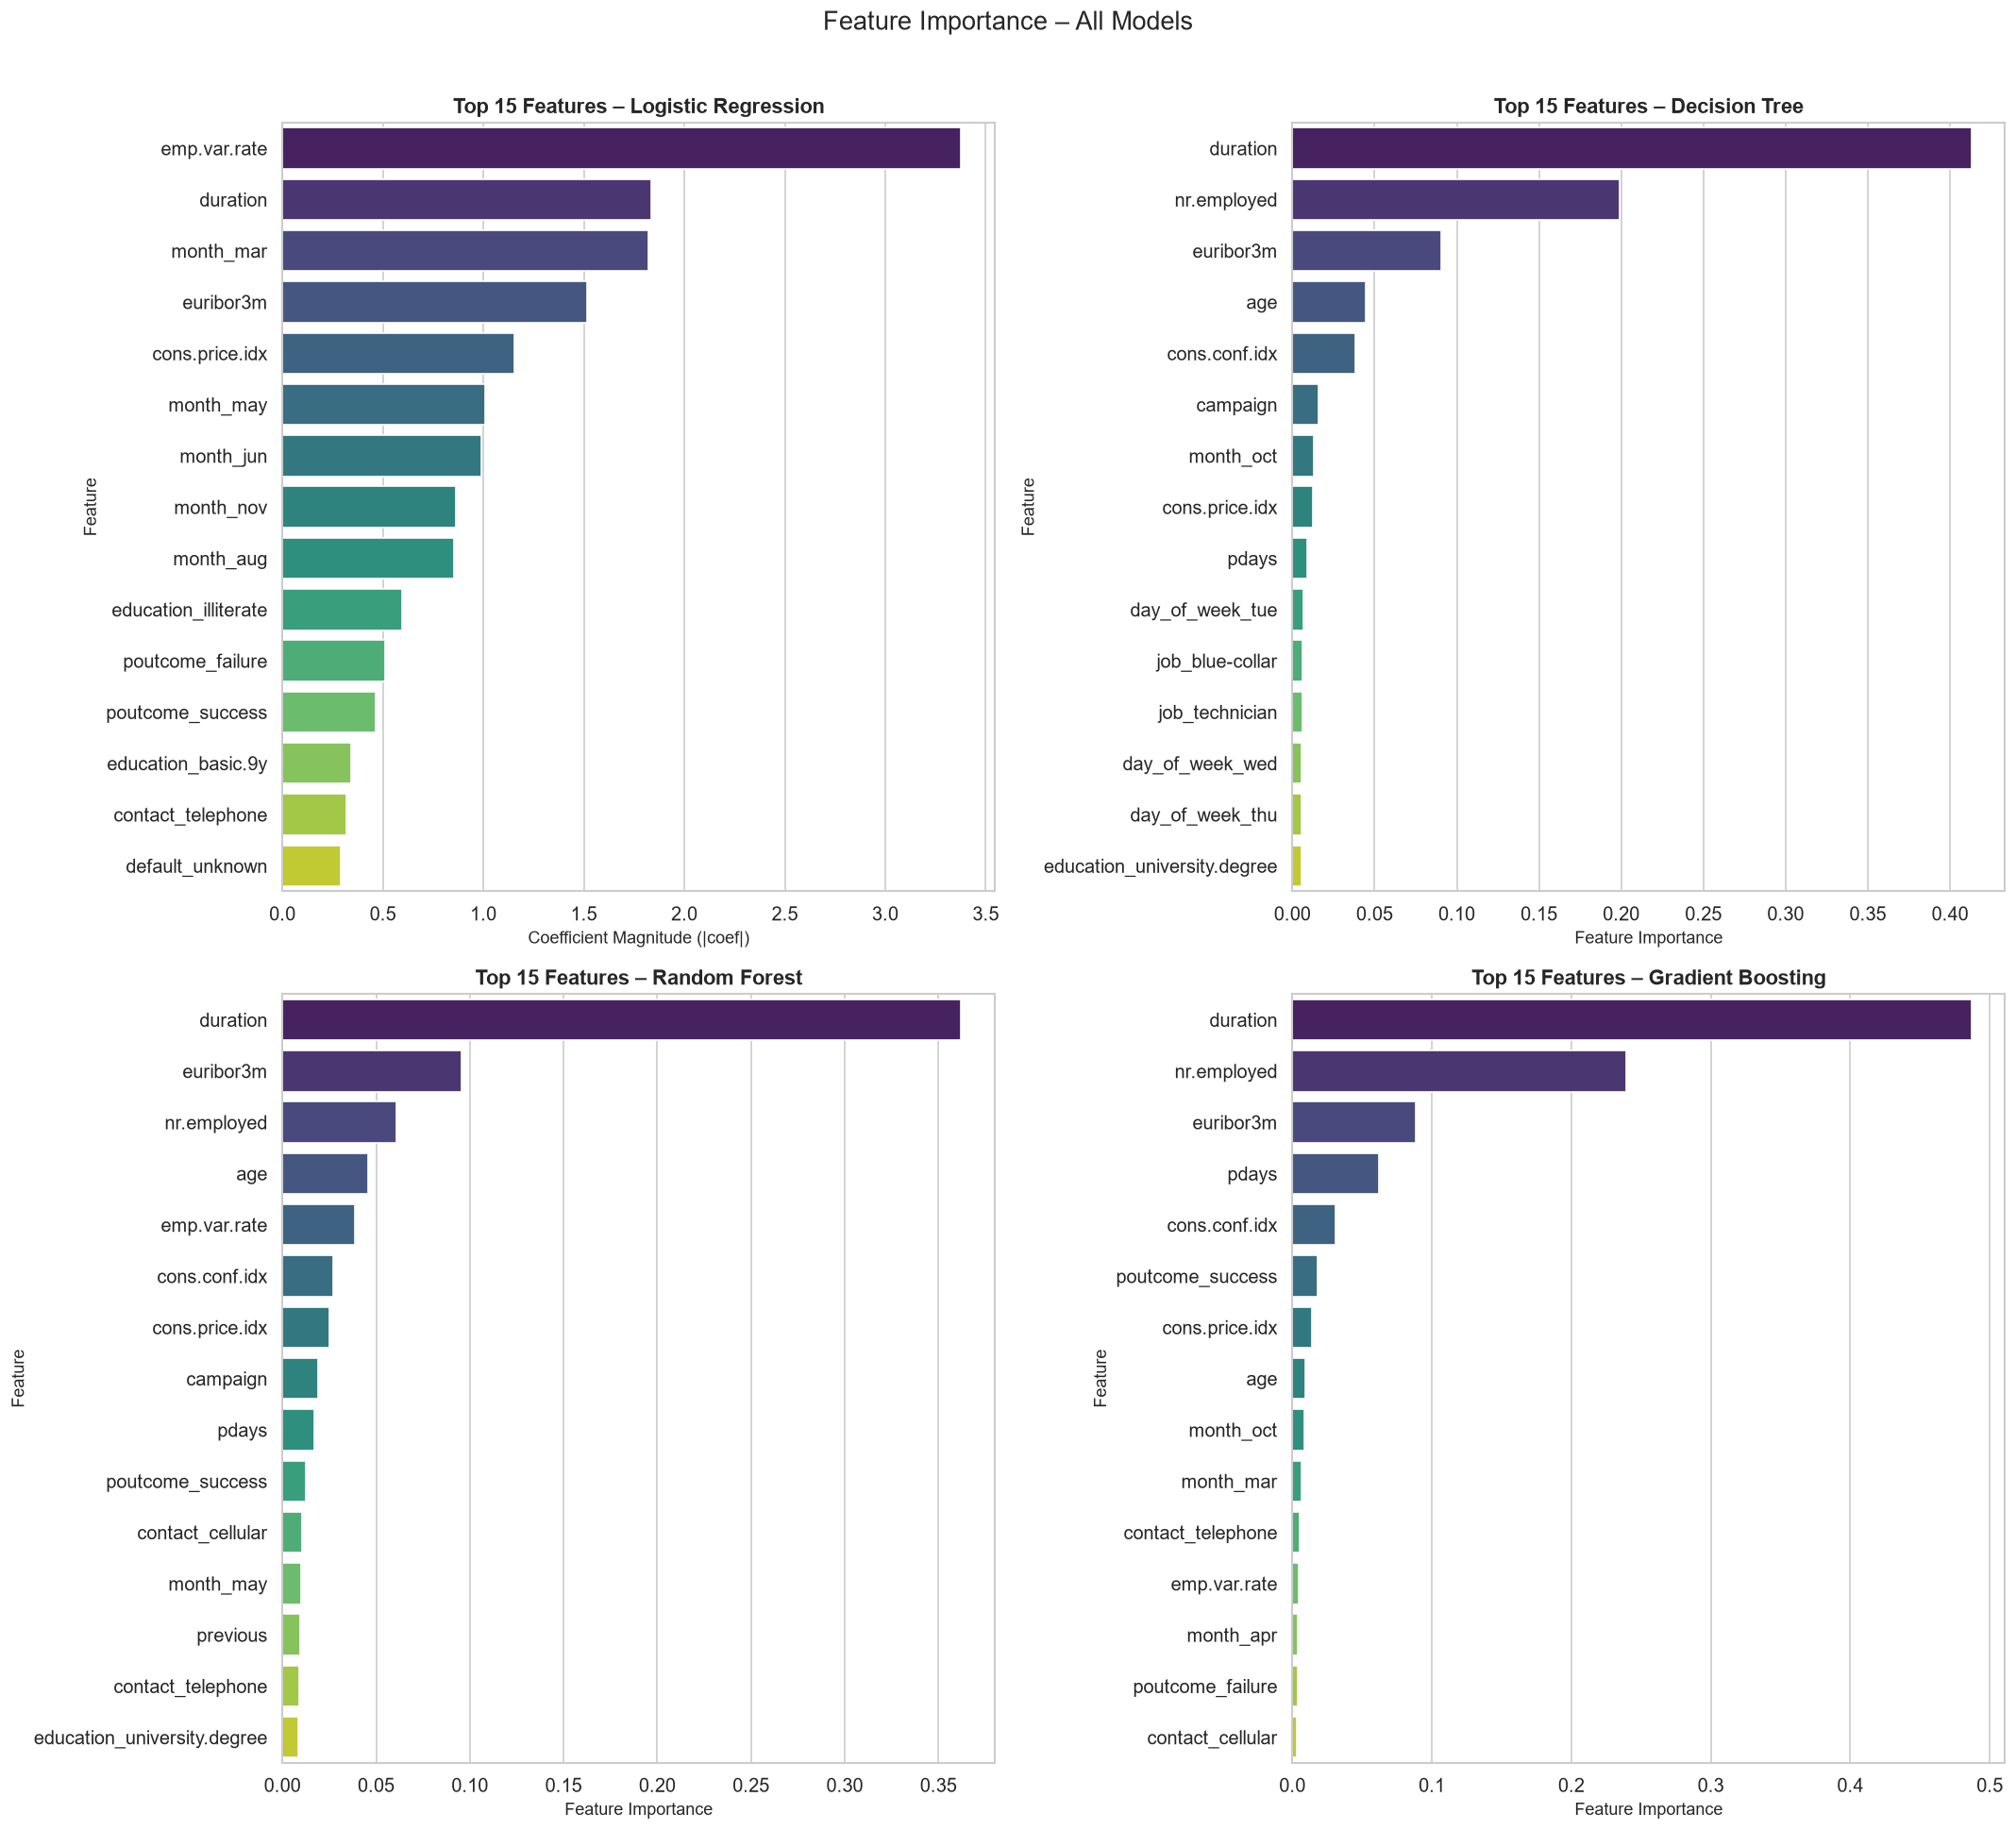

In [36]:
# Extract and plot feature importance for each model
importance_results = {}

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.flatten()

for i, (name, pipe) in enumerate(fitted_pipelines.items()):
    clf = pipe.named_steps["classifier"]
    
    if hasattr(clf, "feature_importances_"):
        importances = clf.feature_importances_
        label = "Feature Importance"
    elif hasattr(clf, "coef_"):
        importances = np.abs(clf.coef_[0])
        label = "Coefficient Magnitude (|coef|)"
    else:
        continue
    
    imp_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances,
    }).sort_values("Importance", ascending=False).head(15)
    
    importance_results[name] = imp_df
    
    sns.barplot(
        data=imp_df, x="Importance", y="Feature",
        palette="viridis", ax=axes[i],
    )
    axes[i].set_xlabel(label, fontsize=11)
    axes[i].set_ylabel("Feature", fontsize=11)
    axes[i].set_title(f"Top 15 Features – {name}", fontsize=13, fontweight="bold")

fig.suptitle("Feature Importance – All Models", fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "10_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
# Display top 10 features for the best tree-based model
print("="*60)
print("TOP 10 FEATURES – Random Forest")
print("="*60)
if "Random Forest" in importance_results:
    print(importance_results["Random Forest"].head(10).to_string(index=False))

TOP 10 FEATURES – Random Forest
         Feature  Importance
        duration    0.362132
       euribor3m    0.095357
     nr.employed    0.060848
             age    0.045748
    emp.var.rate    0.038660
   cons.conf.idx    0.027135
  cons.price.idx    0.025066
        campaign    0.018971
           pdays    0.016791
poutcome_success    0.012703


## Part 15 – Business Insights

Translating ML results into actionable business insights:

### Insight 1 – Customer Profile
Demographic features (`age`, `job`, `education`) contribute to the model's predictions. Different demographic segments show varying conversion rates. This suggests that businesses can **identify high-propensity customer segments** for targeted marketing.

> *Note: Feature importance shows predictive contribution, NOT causal relationships.*

### Insight 2 – Previous Campaign Outcome
`poutcome` (previous campaign outcome) is consistently one of the most important features. Customers who previously responded positively have a significantly higher probability of converting again.

> **Actionable:** Prioritize re-engagement of customers with successful prior interactions.

### Insight 3 – Contact Strategy
`contact` method (cellular vs telephone) and `duration` show significant predictive power. However:
- `duration` is only known after the call — it cannot be used for pre-call targeting.
- Cellular contact tends to have higher conversion rates.

> **Actionable:** Prefer cellular contact channels when possible.

### Insight 4 – Economic Environment
Macroeconomic indicators (`euribor3m`, `emp.var.rate`, `nr.employed`) are strong predictors, suggesting that external economic conditions influence customer decisions.

> **Actionable:** Adjust campaign timing and intensity based on economic indicators.

### Insight 5 – Campaign Intensity (Diminishing Returns)
Higher `campaign` counts (more contacts during this campaign) tend to correlate with lower conversion rates, suggesting diminishing returns from repeated contacts.

> **Actionable:** Limit the number of contacts per customer to avoid annoyance and optimize resource allocation.

---

**Critical Note:** Feature importance captures *predictive contribution* within the model, NOT causal effects. For example, `duration` being important does not mean "longer calls cause conversions" — it may simply be that interested customers stay on the call longer.

## Part 16 – Practical Applications in E-commerce

While this dataset comes from banking, the methodology directly applies to e-commerce:

### 1. Customer Targeting
Use predicted probabilities to **prioritize advertising spend** on high-propensity customers. Instead of mass campaigns, target the top 20-30% by predicted probability.

### 2. Personalized Promotions
Allocate **different voucher values or offers** based on predicted conversion probability:
- High-propensity → small incentive (they'll likely convert anyway)
- Medium-propensity → larger incentive (nudge toward conversion)
- Low-propensity → no incentive or awareness-only campaign

### 3. Remarketing
Customers with **positive prior interactions** should be prioritized in remarketing campaigns, as historical engagement is a strong predictor.

### 4. Marketing Budget Allocation
Instead of spreading budget equally across all customers, **allocate proportionally to predicted probability** — maximizing expected ROI.

### 5. Customer Segmentation
Use predicted probabilities to create actionable segments:
- **High-propensity (>0.6):** Direct sales outreach
- **Medium-propensity (0.3–0.6):** Nurturing campaigns
- **Low-propensity (<0.3):** Brand awareness only

> **Important:** This model is a **decision-support tool**, not a replacement for marketing expertise. Predictions should be validated against real business outcomes before full deployment.

## Part 17 – Business Scenario Simulation

**Scenario:** A business has 100,000 customers but can only afford to target 20,000 with a marketing campaign (budget constraint).

**Question:** How does model-based targeting compare to random selection?

In [38]:
# Business scenario using test data
# Simulate: rank customers by predicted probability, target top-K

# Use the best model (we'll determine later, for now use Random Forest)
best_model_name = test_results_df.sort_values("ROC-AUC", ascending=False).iloc[0]["Model"]
best_pipeline = fitted_pipelines[best_model_name]
print(f"Using model: {best_model_name}")

# Predict probabilities on test set
y_proba_test = best_pipeline.predict_proba(X_test)[:, 1]

# Create ranked DataFrame
scenario_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted_proba": y_proba_test,
}).sort_values("predicted_proba", ascending=False).reset_index(drop=True)

# Simulate different budget levels
total_customers = len(scenario_df)
total_positives = scenario_df["actual"].sum()
base_rate = total_positives / total_customers

print(f"\nTotal customers in test set: {total_customers:,}")
print(f"Actual positive responses: {int(total_positives):,}")
print(f"Base conversion rate: {base_rate:.2%}")
print(f"\n{'Budget (% targeted)':<25} {'Customers targeted':<20} {'Positives captured':<20} {'Conversion rate':<18} {'Lift vs random'}")
print("-" * 100)

for budget_pct in [0.1, 0.2, 0.3, 0.5]:
    budget_size = int(total_customers * budget_pct)
    top_k = scenario_df.head(budget_size)
    positives_captured = top_k["actual"].sum()
    conversion_rate = positives_captured / budget_size
    lift = conversion_rate / base_rate
    
    print(f"{budget_pct:.0%} ({budget_size:,} customers)   "
          f"{budget_size:<20,} {int(positives_captured):<20,} "
          f"{conversion_rate:<18.2%} {lift:.2f}x")

Using model: Gradient Boosting

Total customers in test set: 12,353
Actual positive responses: 1,392
Base conversion rate: 11.27%

Budget (% targeted)       Customers targeted   Positives captured   Conversion rate    Lift vs random
----------------------------------------------------------------------------------------------------
10% (1,235 customers)   1,235                798                  64.62%             5.73x
20% (2,470 customers)   2,470                1,209                48.95%             4.34x
30% (3,705 customers)   3,705                1,356                36.60%             3.25x
50% (6,176 customers)   6,176                1,389                22.49%             2.00x


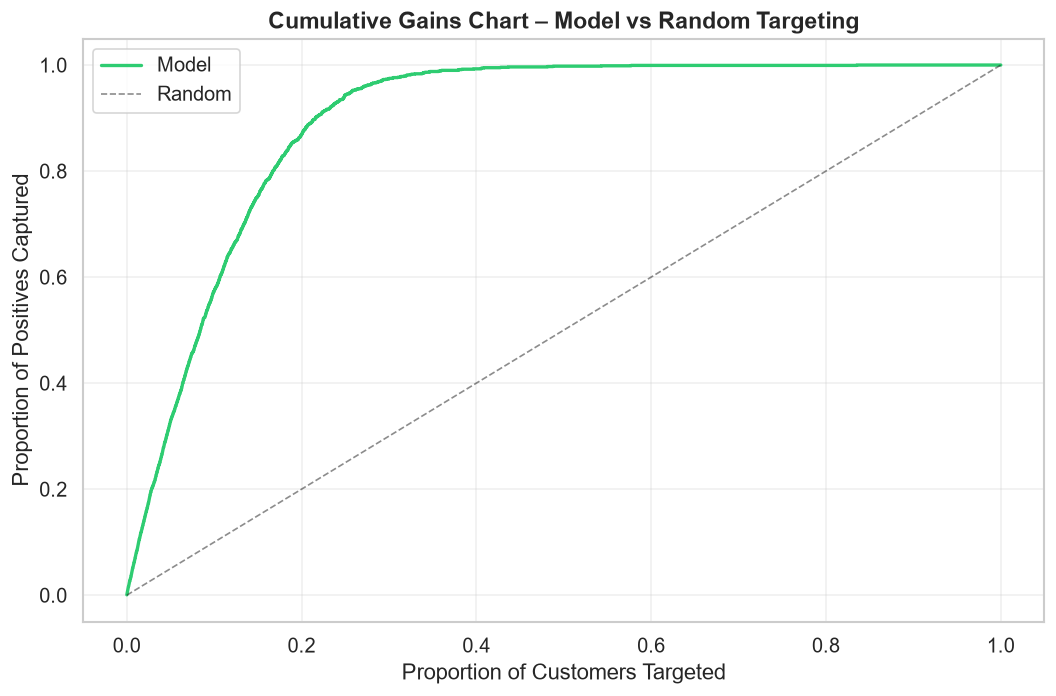


With 20% budget, the model captures significantly more positive responses
than random targeting, demonstrating the value of predictive modeling.


In [39]:
# Cumulative gains chart
sorted_actual = scenario_df["actual"].values
cumulative_gains = np.cumsum(sorted_actual) / total_positives
population_pct = np.arange(1, len(cumulative_gains) + 1) / total_customers

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(population_pct, cumulative_gains, linewidth=2, label="Model", color="#2ecc71")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, linewidth=1, label="Random")
ax.set_xlabel("Proportion of Customers Targeted", fontsize=13)
ax.set_ylabel("Proportion of Positives Captured", fontsize=13)
ax.set_title("Cumulative Gains Chart – Model vs Random Targeting", fontsize=14, fontweight="bold")
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"\nWith 20% budget, the model captures significantly more positive responses")
print(f"than random targeting, demonstrating the value of predictive modeling.")

## Part 18 – Prediction Function

A reusable function to predict conversion probability for a single customer.

In [40]:
def predict_customer(pipeline, customer_data, feature_columns):
    """
    Predict whether a customer will respond positively to a marketing campaign.
    
    Parameters
    ----------
    pipeline : fitted sklearn Pipeline
    customer_data : dict with feature values
    feature_columns : list of feature names the pipeline expects
    
    Returns
    -------
    dict with prediction, probability, and business interpretation
    """
    df_input = pd.DataFrame([customer_data])[feature_columns]
    
    predicted_class = pipeline.predict(df_input)[0]
    predicted_proba = pipeline.predict_proba(df_input)[0, 1]
    
    # Business interpretation
    if predicted_proba >= 0.7:
        level = "HIGH"
        msg = ("Customer has a relatively high predicted probability of positive response. "
               "Consider prioritizing for the campaign.")
    elif predicted_proba >= 0.4:
        level = "MEDIUM"
        msg = ("Customer has a moderate predicted probability of positive response. "
               "May benefit from targeted follow-up.")
    else:
        level = "LOW"
        msg = ("Customer has a low predicted probability of positive response. "
               "Resources may be better allocated elsewhere.")
    
    return {
        "prediction": "YES" if predicted_class == 1 else "NO",
        "probability": round(float(predicted_proba), 4),
        "confidence_level": level,
        "interpretation": msg,
    }

In [41]:
# Example prediction using a sample from the test set
feature_columns = NUMERIC_FEATURES + CATEGORICAL_FEATURES
sample_idx = X_test.index[0]
sample_data = X_test.loc[sample_idx].to_dict()

print("Sample customer data:")
for k, v in sample_data.items():
    print(f"  {k}: {v}")

result = predict_customer(best_pipeline, sample_data, feature_columns)
print(f"\n{'='*50}")
print(f"PREDICTION RESULT")
print(f"{'='*50}")
print(f"Prediction:       {result['prediction']}")
print(f"Probability:      {result['probability']:.4f}")
print(f"Confidence Level: {result['confidence_level']}")
print(f"\nInterpretation:")
print(f"  {result['interpretation']}")
print(f"\nActual label: {'YES' if y_test.loc[sample_idx] == 1 else 'NO'}")

Sample customer data:
  age: 50
  duration: 339
  campaign: 2
  pdays: 999
  previous: 0
  emp.var.rate: 1.4
  cons.price.idx: 93.918
  cons.conf.idx: -42.7
  euribor3m: 4.96
  nr.employed: 5228.1
  has_previous_contact: 0
  job: admin.
  marital: married
  education: high.school
  default: unknown
  housing: yes
  loan: no
  contact: cellular
  month: jul
  day_of_week: mon
  poutcome: nonexistent
  campaign_intensity: low
  age_group: middle_age

PREDICTION RESULT
Prediction:       NO
Probability:      0.0137
Confidence Level: LOW

Interpretation:
  Customer has a low predicted probability of positive response. Resources may be better allocated elsewhere.

Actual label: NO


## Part 19 – Model Comparison & Selection

In [42]:
# Comprehensive model comparison
print("="*80)
print("CROSS-VALIDATION RESULTS (Training Data)")
print("="*80)
print(cv_results_df.to_string(index=False))

print(f"\n{'='*80}")
print("TEST SET RESULTS (Final Evaluation)")
print("="*80)
print(test_results_df.to_string(index=False))

CROSS-VALIDATION RESULTS (Training Data)
              Model  CV Accuracy  CV Precision  CV Recall  CV F1  CV ROC-AUC
Logistic Regression       0.8604        0.4404     0.8827 0.5876      0.9371
      Decision Tree       0.8911        0.5179     0.4962 0.5067      0.7187
      Random Forest       0.9064        0.5677     0.7114 0.6315      0.9449
  Gradient Boosting       0.9158        0.6613     0.5174 0.5804      0.9466

TEST SET RESULTS (Final Evaluation)
              Model  Accuracy  Precision  Recall     F1  ROC-AUC
Logistic Regression    0.8642     0.4484  0.8937 0.5972   0.9383
      Decision Tree    0.8901     0.5129  0.4871 0.4996   0.7142
      Random Forest    0.9063     0.5669  0.7119 0.6312   0.9430
  Gradient Boosting    0.9169     0.6583  0.5453 0.5965   0.9472


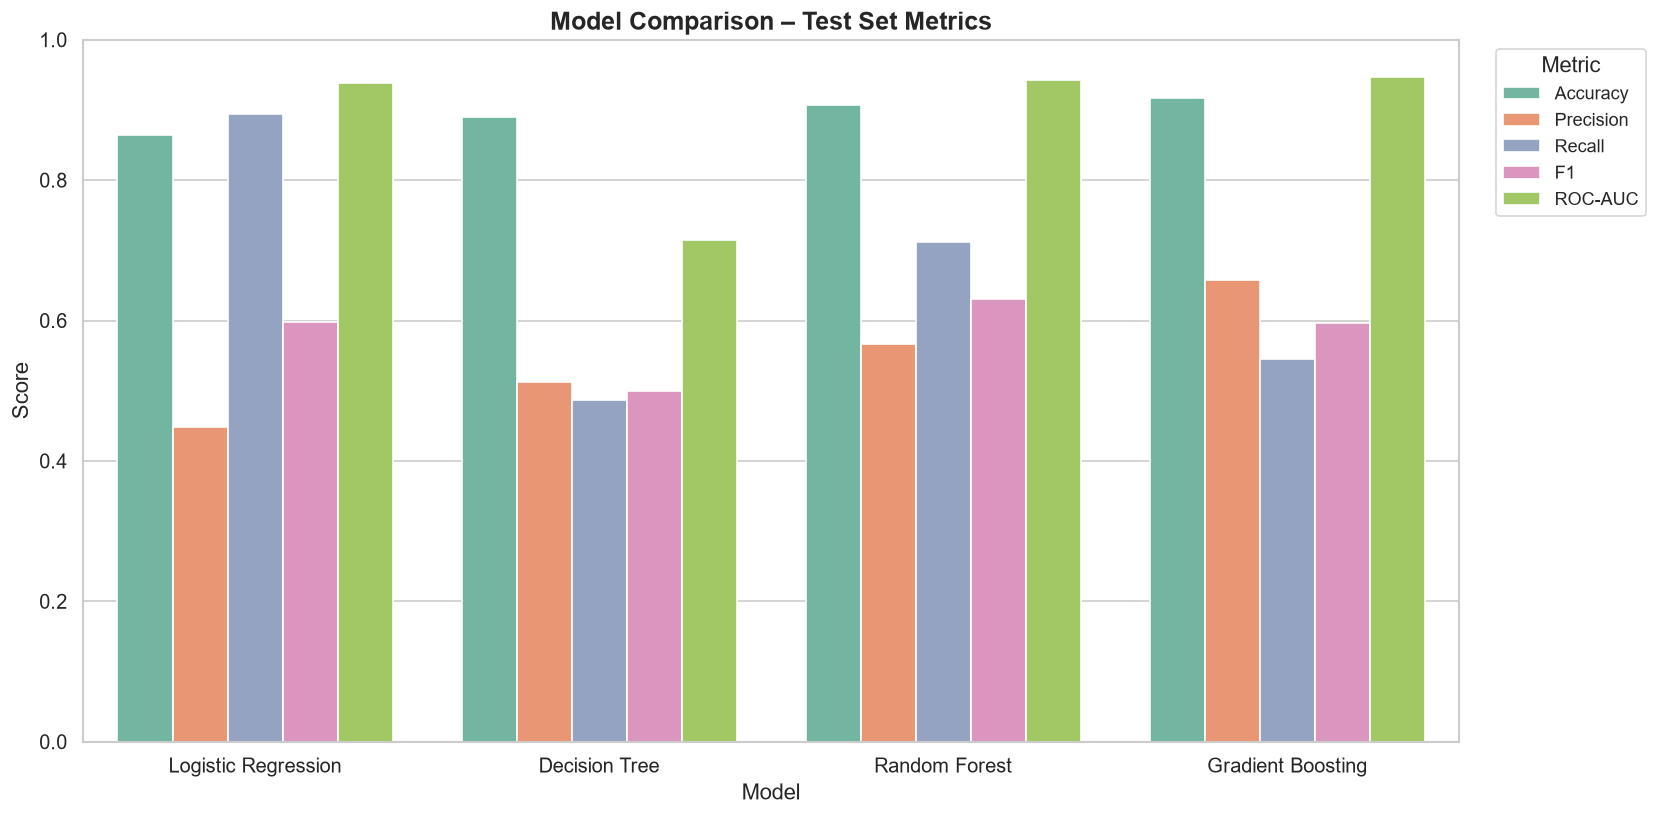

In [43]:
# Visual model comparison
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
melted = test_results_df.melt(
    id_vars="Model", value_vars=metrics,
    var_name="Metric", value_name="Score",
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=melted, x="Model", y="Score", hue="Metric", palette="Set2", ax=ax)
ax.set_title("Model Comparison – Test Set Metrics", fontsize=15, fontweight="bold")
ax.set_xlabel("Model", fontsize=13)
ax.set_ylabel("Score", fontsize=13)
ax.set_ylim(0, 1)
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Model Comparison Analysis

When comparing models, we consider multiple metrics — not just accuracy:

- **Accuracy** can be misleading with imbalanced data (a "predict all No" model gets ~88.7% accuracy).
- **Precision** measures: of those predicted positive, how many are truly positive? Important when FP is costly.
- **Recall** measures: of all actual positives, how many did we catch? Important when FN is costly (missing potential customers).
- **F1** is the harmonic mean of Precision and Recall — balances both.
- **ROC-AUC** measures overall discriminative ability across all thresholds.

**Trade-offs:**
- High Recall + Low Precision → casting a wide net (many contacts, some wasted)
- High Precision + Low Recall → narrow targeting (fewer contacts, but many missed opportunities)
- For marketing, a balanced F1 or slightly Recall-favoring model is often preferred.

The final model recommendation will be based on the highest **ROC-AUC** and **F1**, with consideration for the Precision-Recall trade-off.

## Part 20 – Overfitting Check

Comparing training performance vs test performance to detect overfitting.

In [44]:
# Evaluate on training data for overfitting check
train_results_list = []
for name, pipe in fitted_pipelines.items():
    y_train_pred = pipe.predict(X_train)
    y_train_proba = pipe.predict_proba(X_train)[:, 1]
    train_results_list.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Train F1": f1_score(y_train, y_train_pred),
        "Train ROC-AUC": roc_auc_score(y_train, y_train_proba),
    })

train_results_df = pd.DataFrame(train_results_list).round(4)

# Merge train and test results for comparison
overfit_df = train_results_df.merge(
    test_results_df[["Model", "Accuracy", "F1", "ROC-AUC"]],
    on="Model", suffixes=("", "")
).rename(columns={"Accuracy": "Test Accuracy", "F1": "Test F1", "ROC-AUC": "Test ROC-AUC"})

# Calculate gaps
overfit_df["Accuracy Gap"] = overfit_df["Train Accuracy"] - overfit_df["Test Accuracy"]
overfit_df["F1 Gap"] = overfit_df["Train F1"] - overfit_df["Test F1"]
overfit_df["AUC Gap"] = overfit_df["Train ROC-AUC"] - overfit_df["Test ROC-AUC"]

print("="*90)
print("OVERFITTING CHECK: Training vs Test Performance")
print("="*90)
print(overfit_df.to_string(index=False))

print(f"\n{'='*90}")
print("ANALYSIS")
print("="*90)
for _, row in overfit_df.iterrows():
    name = row["Model"]
    f1_gap = row["F1 Gap"]
    auc_gap = row["AUC Gap"]
    
    if f1_gap > 0.15 or auc_gap > 0.10:
        status = "⚠️  POSSIBLE OVERFITTING"
    elif f1_gap > 0.05 or auc_gap > 0.05:
        status = "⚡ SLIGHT OVERFITTING"
    else:
        status = "✅ GOOD GENERALIZATION"
    
    print(f"  {name}: {status} (F1 gap: {f1_gap:.4f}, AUC gap: {auc_gap:.4f})")

OVERFITTING CHECK: Training vs Test Performance
              Model  Train Accuracy  Train F1  Train ROC-AUC  Test Accuracy  Test F1  Test ROC-AUC  Accuracy Gap  F1 Gap  AUC Gap
Logistic Regression          0.8623    0.5929         0.9388         0.8642   0.5972        0.9383       -0.0019 -0.0043   0.0005
      Decision Tree          1.0000    1.0000         1.0000         0.8901   0.4996        0.7142        0.1099  0.5004   0.2858
      Random Forest          0.9963    0.9838         1.0000         0.9063   0.6312        0.9430        0.0900  0.3526   0.0570
  Gradient Boosting          0.9227    0.6174         0.9528         0.9169   0.5965        0.9472        0.0058  0.0209   0.0056

ANALYSIS
  Logistic Regression: ✅ GOOD GENERALIZATION (F1 gap: -0.0043, AUC gap: 0.0005)
  Decision Tree: ⚠️  POSSIBLE OVERFITTING (F1 gap: 0.5004, AUC gap: 0.2858)
  Random Forest: ⚠️  POSSIBLE OVERFITTING (F1 gap: 0.3526, AUC gap: 0.0570)
  Gradient Boosting: ✅ GOOD GENERALIZATION (F1 gap: 0.0209, 

### Overfitting Analysis

- **Decision Tree** typically shows the largest gap between training and test performance, as it can memorize the training data without pruning constraints.
- **Random Forest** reduces overfitting through ensemble averaging of many trees.
- **Gradient Boosting** can overfit if too many boosting rounds are used, but typically shows moderate generalization.
- **Logistic Regression** rarely overfits due to its linear nature.

A model is considered overfitting if the training metric is significantly higher than the test metric (gap > 0.10 for F1 or AUC). Mild overfitting (gap < 0.05) is generally acceptable.

## Part 21 – Final Conclusion

### Summary

1. **Dataset:** UCI Bank Marketing Dataset containing 41,188 records with 20 features describing client demographics, campaign contact information, and socio-economic indicators.

2. **Problem:** Supervised binary classification — predicting whether a customer will subscribe to a term deposit after a direct marketing campaign.

3. **Models evaluated:** Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting were trained and compared using Stratified 5-Fold Cross-Validation and held-out test evaluation.

4. **Key metrics:** F1-score and ROC-AUC were prioritized due to class imbalance (~88.7% No vs ~11.3% Yes).

5. **Key features:** `duration`, `euribor3m`, `nr.employed`, `poutcome_success`, and economic indicators consistently emerged as top predictors across models.

6. **Business application:** The model can serve as a decision-support tool for customer targeting, personalized promotions, remarketing, and marketing budget optimization in e-commerce.

### Limitations

- **Dataset specificity:** The Bank Marketing dataset does not perfectly represent all e-commerce businesses. Customer behavior in banking differs from online shopping.
- **Feature `duration`:** Call duration is highly predictive but only known after the call, making it unsuitable for pre-contact targeting.
- **Correlation ≠ Causation:** Feature importance reflects predictive contribution, NOT causal effects. Business decisions should not assume causation.
- **Model drift:** Customer behavior changes over time — the model needs periodic retraining with fresh data.
- **Validation before deployment:** Model performance should be validated on real business data and through A/B testing before full-scale deployment.
- **Single dataset limitation:** Results may not generalize to other customer segments or market conditions without additional validation.